# Exploratory Data Analysis for BRaTs 2021 Dataset

The goal of this notebook is to extract insights from BRaTs Dataset to modify existing EMCAD code

## Macro Level Understanding

File Structure:

``` css
└── archive
    ├── BraTS2021_00495
    ├── BraTS2021_00621
    └── BraTS2021_Training_Data
```

Kaggle included 2 test cases outside the full training size for convenience. 

Each training data folder looks like this:
``` css
├── BraTS2021_ID_flair.nii.gz
├── BraTS2021_ID_seg.nii.gz
├── BraTS2021_ID_t1.nii.gz
├── BraTS2021_ID_t1ce.nii.gz
└── BraTS2021_ID_t2.nii.gz
```

*These files were given as TAR files that need to be extracted, the .nii.gz files do not need to be extracted*

***What are these modalities?***
 {'flair', 'seg', 't1', 't1ce', 't2'}

**BRaTs Modality Reference**

| Modality | Full Name | What it shows | Role in BRaTs |
|---|---|---|---|
| `flair` | Fluid Attenuated Inversion Recovery | Suppresses CSF fluid signal, highlights edema and lesions | Best for visualizing **edema (ED)** around tumor |
| `t1` | T1-weighted MRI | Standard anatomical scan, CSF appears dark | Baseline anatomical reference |
| `t1ce` | T1-weighted Contrast Enhanced | T1 with gadolinium contrast injected | Best for visualizing **enhancing tumor (ET)** — lights up with contrast |
| `t2` | T2-weighted MRI | CSF appears bright, good for fluid/tissue distinction | Good for visualizing **necrotic core (NCR)** and overall tumor region |
| `seg` | Segmentation Mask | Not an MRI scan — it's the ground truth label map | Contains labels: `0`=background, `1`=NCR, `2`=ED, `4`=ET |

---

**Key Terms**

| Term | Full Name | Simple Definition |
|---|---|---|
| `CSF` | Cerebrospinal Fluid | Clear fluid that surrounds and cushions the brain and spinal cord |
| `NCR` | Necrotic Core | Dead tissue at the center of the tumor |
| `ED` | Edema | Swelling/fluid buildup around the tumor |
| `ET` | Enhancing Tumor | Active, aggressive tumor region that absorbs contrast dye |
| `gadolinium` | Gadolinium contrast agent | A dye injected into the bloodstream that makes active tumor regions brighter on T1ce scans |
| `label map` | Segmentation Label Map | An image where each pixel/voxel is assigned a number representing its class (e.g. `0`=background, `1`=NCR) |
| `voxel` | Volumetric Pixel | The 3D equivalent of a pixel — a small cube of volume in a 3D scan |


*table generated by claude*

In [77]:
# directory and file handling
import os

**How many samples?**

In [78]:
# Its 1251

## Micro level understanding

In [79]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
# !pip install nibabel
import nibabel as nib

**Case Study ID = 00495**

In [ ]:
# Load the NIfTI ( Neuroimaging Informatics Technology ) files for the case
# .nii.gz is a compressed version of .nii, which is used to store medical image data
flair = nib.load('data/archive/BraTS2021_00495/BraTS2021_00495_flair.nii.gz')
seg = nib.load('data/archive/BraTS2021_00495/BraTS2021_00495_seg.nii.gz')
t1 = nib.load('data/archive/BraTS2021_00495/BraTS2021_00495_t1.nii.gz')
t1ce = nib.load('data/archive/BraTS2021_00495/BraTS2021_00495_t1ce.nii.gz')
t2 = nib.load('data/archive/BraTS2021_00495/BraTS2021_00495_t2.nii.gz')



# Extract the image as numpy arrays
flair_data = flair.get_fdata()
seg_data = seg.get_fdata()
t1_data = t1.get_fdata()
t1ce_data = t1ce.get_fdata()
t2_data = t2.get_fdata()


In [82]:
# Shape
for modality, data in zip(['FLAIR', 'SEG', 'T1', 'T1CE', 'T2'], [flair_data, seg_data, t1_data, t1ce_data, t2_data]):
    print(f"{modality} shape: {data.shape}")

print("\nShape is most likely Height = 240, Width = 240, Depth (Number of Slices) = 155.")

FLAIR shape: (240, 240, 155)
SEG shape: (240, 240, 155)
T1 shape: (240, 240, 155)
T1CE shape: (240, 240, 155)
T2 shape: (240, 240, 155)

Shape is most likely Height = 240, Width = 240, Depth (Number of Slices) = 155.


In [ ]:
# unique values
for modality, data in zip(['FLAIR', 'SEG', 'T1', 'T1CE', 'T2'], [flair_data, seg_data, t1_data, t1ce_data, t2_data]):
    print(f"{modality} unique vals: {len(np.unique(data))}")

print("\nSEG Values:")
print(np.unique(seg_data))

print("\nKaggle Description of SEG values:")
print("""
      Annotations comprise the GD-enhancing tumor (ET — label 4)
      the peritumoral edematous/invaded tissue (ED — label 2) and the
      necrotic tumor core (NCR — label 1), as described both in the 
      BraTS 2012-2013 TMI paper and in the latest BraTS summarizing paper""")

label = {0: "BG", 1: "NCR", 2: "ED", 4: "ET"}

FLAIR unique vals: 2184
SEG unique vals: 4
T1 unique vals: 4688
T1CE unique vals: 9979
T2 unique vals: 2391

SEG Values:
[0. 1. 2. 4.]

Kaggle Description of SEG values:

      Annotations comprise the GD-enhancing tumor (ET — label 4)
      the peritumoral edematous/invaded tissue (ED — label 2) and the
      necrotic tumor core (NCR — label 1), as described both in the 
      BraTS 2012-2013 TMI paper and in the latest BraTS summarizing paper


**Visualization**

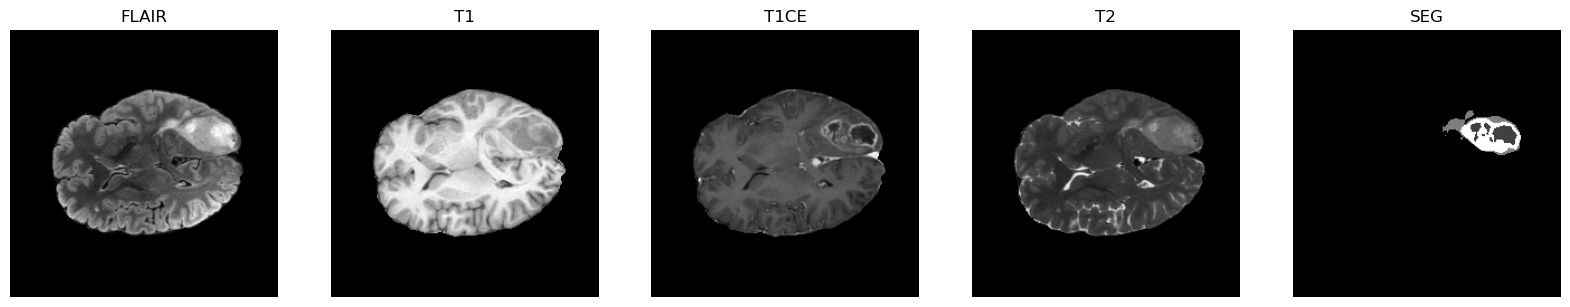

In [84]:
# Plot the middle slice for all modalities
mid_idx = seg.shape[2] // 2
fig, axes = plt.subplots(nrows=1,ncols=5, figsize=(20, 4))
for ax, modality, data in zip(axes, ['FLAIR', 'T1', 'T1CE', 'T2', 'SEG'], [flair_data, t1_data, t1ce_data, t2_data, seg_data]):
    ax.imshow(data[:, :, mid_idx], cmap='gray') # specifying grayscale to map the numbers correctly
    ax.set_title(modality)
    ax.axis('off')


In [85]:
# Are values normalized?: NO
def describe(arr):
    print(f"mean:  {arr.mean():.4f}")
    print(f"std:   {arr.std():.4f}")
    print(f"min:   {arr.min():.4f}")
    print(f"max:   {arr.max():.4f}")

for modality, data in zip(['FLAIR', 'SEG', 'T1', 'T1CE', 'T2'], [flair_data, seg_data, t1_data, t1ce_data, t2_data]):
    print(f"{modality}")
    print(f"{describe(data)}\n")

FLAIR
mean:  134.1548
std:   334.1743
min:   0.0000
max:   2289.0000
None

SEG
mean:  0.0271
std:   0.2826
min:   0.0000
max:   4.0000
None

T1
mean:  476.9808
std:   1114.9392
min:   0.0000
max:   6402.0000
None

T1CE
mean:  522.1012
std:   1238.2931
min:   0.0000
max:   12299.0000
None

T2
mean:  106.8401
std:   267.2138
min:   0.0000
max:   2508.0000
None



***When normalizing do we include the background?***

We will use the masked version to ignore background 0s.

In [88]:
# Normalize the value
flair_data_1 = flair_data.copy()
flair_data_2 = flair_data.copy()
t1_data_1 = t1_data.copy()
t1_data_2 = t1_data.copy()
t1ce_data_1 = t1ce_data.copy()
t1ce_data_2 = t1ce_data.copy()
t2_data_1 = t2_data.copy()
t2_data_2 = t2_data.copy()


modalities = [
    ("FLAIR", flair_data_1, flair_data_2),
    ("T1",    t1_data_1,    t1_data_2),
    ("T1CE",  t1ce_data_1,  t1ce_data_2),
    ("T2",    t2_data_1,    t2_data_2),
]

def z_score_no_mask(volume):
    volume = volume - volume.mean()
    volume = volume / volume.std()
    return volume

def z_score_mask(volume):
    mask = volume > 0
    mean = volume[mask].mean()
    std  = volume[mask].std()
    volume[mask] = (volume[mask] - mean) / std
    return volume

for name, no_mask, masked in modalities:
    no_mask = z_score_no_mask(no_mask)
    masked  = z_score_mask(masked)
    
    print(f"{name} NO MASK")
    describe(no_mask)
    print(f"{name} MASK")
    describe(masked)
    print()

FLAIR NO MASK
mean:  0.0000
std:   1.0000
min:   -0.4015
max:   6.4483
FLAIR MASK
mean:  0.0000
std:   0.4062
min:   -2.2682
max:   4.1784

T1 NO MASK
mean:  -0.0000
std:   1.0000
min:   -0.4278
max:   5.3142
T1 MASK
mean:  -0.0000
std:   0.4062
min:   -3.7969
max:   4.7119

T1CE NO MASK
mean:  -0.0000
std:   1.0000
min:   -0.4216
max:   9.5106
T1CE MASK
mean:  0.0000
std:   0.4062
min:   -3.1127
max:   9.4631

T2 NO MASK
mean:  0.0000
std:   1.0000
min:   -0.3998
max:   8.9859
T2 MASK
mean:  0.0000
std:   0.4062
min:   -2.2496
max:   6.4727



## EMCAD

***How does the existing code handle normalization?***


----
SYNAPSE PREPROCESSING: 


They scale using known limits.
```python
    upper = 275 
    lower = -125
    ...
    for ct_file in os.listdir(ct_path):
        ...
        ct_array = np.clip(ct_array, lower, upper)
        ct_array = (ct_array - lower) / (upper - lower)
        ...

```

Unnecessary for our use case since Synapse uses Hounsfield Units, a standard for every CT scanner.

----



The majority of the scripts use some sort of normalization over the global mean, but we will use the way listed above and do it all at once before training.
```python
transforms.Normalize([0.485, 0.456, 0.406],
                    [0.229, 0.224, 0.225])])
```


***How does the existing code handle number of modalities?***


----

``` python 
class PyramidVisionTransformerImpr(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, ...):
        ...
````

The synapse dataset has a single channel so they use a trick to merge 3 concurrent slices to get a 3d channel. 

```python
        for s_idx in range(ct_array.shape[0]-2):
            #ct_array_s = np.zeros()
    	    ct_array_s = np.transpose(ct_array, (1, 2, 0))[:, :, s_idx:s_idx+3]
    	    print(ct_array_s.shape)
    	    seg_array_s = seg_array[s_idx+1, :, :]
    	    slice_no = "{:03d}".format(s_idx)
    	    new_ct_name = ct_number.replace('img', 'case') + '_slice' + slice_no
    	    np.savez(os.path.join(save_path, new_ct_name), image=ct_array_s, label=seg_array_s)
```

We will choose 3 modalities per supervisor instruction

INCLUDE: T1, T1CE, FLAIR

EXCLUDE T2

----

***How does the existing code handle resizing?***


----

In terms of image shape:

``` python 
...
A.Resize(height=self.trainsize, width=self.trainsize),
...
```

We will adopt this with the known encoder size at 224

----



In terms of the data shape:

``` python 
        ct_array = np.transpose(ct_array, (2, 0, 1))
        seg_array = np.transpose(seg_array, (2, 0, 1))
```

We will adopt this with the slice dimension first.



***How does the existing code handle the ground truth?***

BRaTs includes labels 
[0,1,2,4]


```python

class DiceLoss(nn.Module):
    def __init__(self, n_classes):
        super(DiceLoss, self).__init__()
        self.n_classes = n_classes

    def _one_hot_encoder(self, input_tensor):
        tensor_list = []
        for i in range(self.n_classes):
            temp_prob = input_tensor == i  # * torch.ones_like(input_tensor)
            tensor_list.append(temp_prob.unsqueeze(1))
        output_tensor = torch.cat(tensor_list, dim=1)
        return output_tensor.float()

    def _dice_loss(self, score, target):
        target = target.float()
        smooth = 1e-5
        intersect = torch.sum(score * target)
        y_sum = torch.sum(target * target)
        z_sum = torch.sum(score * score)
        loss = (2 * intersect + smooth) / (z_sum + y_sum + smooth)
        loss = 1 - loss
        return loss

```


The issue is 

```python
for i in range(self.n_classes):
```


This will iterate 0,1,2,3 and will not find 4.

So in our preprocessing we must map 4 to 3.




## Write!
```bash
preprocess_brats.py
dataloader_brats.py
```